# Analítica de Datos
### LTIN
## Diego Samuel María González
### 11/09/2026
### Código: 218869748

## Actividad 6

## Importación de librerías y Generación de datos

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Generamos datos sintéticos reproducibles (random_state fijo)
X, y = make_classification(
    n_samples=500,   # número de muestras
    n_features=2,    # 2 características para poder graficar en 2D
    n_redundant=0,   # sin características redundantes
    n_informative=2, # ambas características son informativas
    n_clusters_per_class=1,
    class_sep=1.2,   # separación entre clases (más grande = más fácil)
    random_state=42
    )

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Clases (conteo):", dict(zip(*np.unique(y, return_counts=True))))
    

X shape: (500, 2)
y shape: (500,)
Clases (conteo): {np.int64(0): np.int64(249), np.int64(1): np.int64(251)}


## Visualización de los datos generados

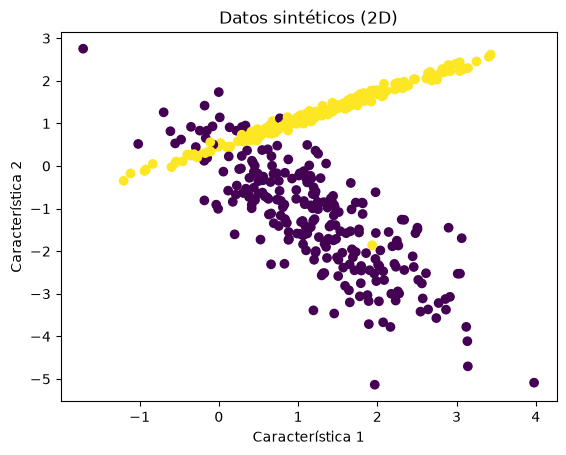

In [3]:
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Datos sintéticos (2D)")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.show()

## Separación de datos (Train/Test)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2,
random_state=42,
stratify=y # mantiene proporciones de clases
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (400, 2) Test: (100, 2)


## Creación de pipeline y Entrenamiento del modelo

In [5]:
# Creamos el pipeline
model = Pipeline(steps=[
("scaler", StandardScaler()),
("clf", LogisticRegression(random_state=42))
])
# Entrenamos
model.fit(X_train, y_train)
print("Modelo entrenado")

Modelo entrenado


## Evaluación del modelo

In [6]:
# Predicciones en el conjunto de prueba
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)
print("Accuracy:", round(acc, 4))
print("\nMatriz de confusión:\n", cm)
print("\nReporte de clasificación:\n", report)

Accuracy: 0.91

Matriz de confusión:
 [[44  6]
 [ 3 47]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.94      0.88      0.91        50
           1       0.89      0.94      0.91        50

    accuracy                           0.91       100
   macro avg       0.91      0.91      0.91       100
weighted avg       0.91      0.91      0.91       100



## Graficación de los resultados del entrenamiento

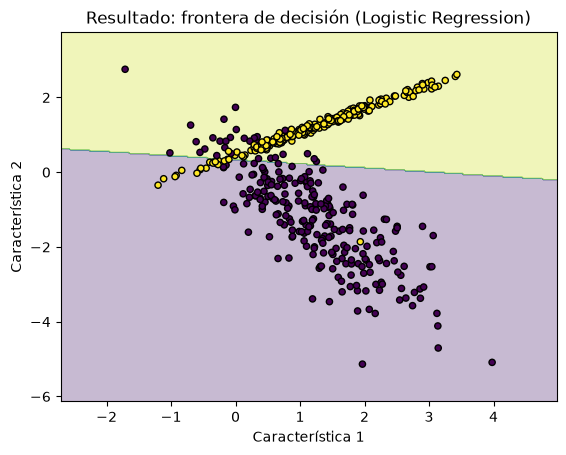

In [8]:
# Función auxiliar para dibujar frontera de decisión en 2D
def plot_decision_boundary(model, X, y, title="Frontera de decisión"):
    # Definimos una malla (grid) en el espacio 2D
    x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
    y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0
    xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid).reshape(xx.shape)
    plt.figure()
    plt.contourf(xx, yy, preds, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", s=20)
    plt.title(title)
    plt.xlabel("Característica 1")
    plt.ylabel("Característica 2")
    plt.show()
# Graficamos usando TODO el dataset (solo para visualización)
plot_decision_boundary(model, X, y, title="Resultado: frontera de decisión (Logistic Regression)")